# Importação de Bibliotecas

In [ ]:
!pip install --upgrade datasets
import os
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from datasets import Dataset
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
df = pd.read_pickle("symbolic_test_df.pkl")

In [ ]:
pd.set_option('display.max_colwidth', None)
df[df["predicted_useful"] == 0].sample(5)

,recommendationid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,feature_density,useful,average_sentence_length_norm,token_count_norm,sentence_count_norm,sent_intensity_norm,smog_grade_norm,feature_count_norm,nota_final,predicted_useful
1190129,29649497,brazilian,nao consigo nem abrir o jogo\n,1486044926,1486044926,False,4,0,0.465257,0,...,0.0,0,0.199596,0.043165,0.2,1.000000,0.530829,0.00,0.437278,0
1468287,74642018,brazilian,Jogo bom para pensar e treinar calculos matematicos basico,1597971467,1597971467,True,10,0,0.500942,0,...,0.0,1,0.299395,0.064748,0.2,0.857143,0.650267,0.00,0.438463,0
2627989,30490872,brazilian,"Jogo mto bom, já fazia um tempo que queria ele, esperei cair o preço e comprei, vale cada centavo!",1489413963,1489413963,True,5,0,0.565217,0,...,0.0,1,0.765120,0.165468,0.2,0.335404,0.601026,0.00,0.426806,0
1700302,33249309,brazilian,"Complexidade simplória. Não jogue caso tenha labirintite, fiquei com dor de cabeça, muito bom!",1499203535,1499203535,True,6,2,0.615385,0,...,0.0,1,0.299395,0.129496,0.4,0.857143,0.601026,0.00,0.460013,0
2236254,110073718,brazilian,é só pra um personagem,1644684645,1644684645,False,52,13,0.729092,0,...,0.2,1,0.166330,0.035971,0.2,0.000000,0.530829,0.25,0.151579,0


In [ ]:
dataset = Dataset.from_pandas(df)

In [ ]:
model_path = "/content/drive/MyDrive/results/checkpoint-2650"

tokenizer = AutoTokenizer.from_pretrained(model_path)

device = torch.device("cuda")

model = AutoModelForSequenceClassification.from_pretrained(
    model_path
)

model.to(device)
model.eval()

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(torch.cuda.is_available())
print(next(model.parameters()).device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

True
cuda:0


In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["review"],
        truncation=True,
        max_length=128
    )

tokenized = dataset.map(tokenize, batched=True)

tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask"]
)

Map:   0%|          | 0/40591 [00:00<?, ? examples/s]

In [ ]:
tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask"]
)

In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(
    tokenized,
    batch_size=64,
    collate_fn=data_collator
)

In [ ]:
batch = next(iter(loader))
batch = {k: v.to(device) for k, v in batch.items()}

with torch.no_grad():
    outputs = model(**batch)

print(outputs.logits.shape)

torch.Size([64, 2])


In [ ]:
predictions = []

with torch.no_grad():
    for batch in loader:

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        outputs = model(**batch)

        preds = outputs.logits.argmax(dim=-1)

        predictions.extend(preds.cpu().tolist())

In [ ]:
df["sub_pred"] = predictions

In [ ]:
df = df.rename(columns={
    "predicted_useful": "symbolic_pred"
})

In [ ]:
agreement = (
    df["symbolic_pred"] ==
    df["sub_pred"]
).mean()

print(f"Agreement: {agreement:.2%}")

Agreement: 63.98%


In [ ]:
from sklearn.metrics import classification_report
print("SYMBOLIC")

print(
    classification_report(
        df["useful"],
        df["symbolic_pred"]
    )
)

print("SUBSYMBOLIC")

print(
    classification_report(
        df["useful"],
        df["sub_pred"]
    )
)

SYMBOLIC
              precision    recall  f1-score   support

           0       0.09      0.35      0.14      3076
           1       0.93      0.70      0.80     37515

    accuracy                           0.67     40591
   macro avg       0.51      0.53      0.47     40591
weighted avg       0.87      0.67      0.75     40591

SUBSYMBOLIC
              precision    recall  f1-score   support

           0       0.20      0.67      0.31      3076
           1       0.97      0.78      0.87     37515

    accuracy                           0.77     40591
   macro avg       0.58      0.73      0.59     40591
weighted avg       0.91      0.77      0.82     40591



In [ ]:
disagreements = df[
    df["symbolic_pred"] != df["sub_pred"]
]

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
disagreements[
    [
        "review",
        "useful",
        "symbolic_pred",
        "sub_pred"
    ]
].sample(20)

,review,useful,symbolic_pred,sub_pred
1853307,"Se voce comprou o jogo pra tentar lucrar com cartas, pode parar por ai... ''não deu certo '-'...\n\nOlha o jogo é bom 8Bits, Divertido e feito por um br. ficou legal....\nDark souls n se compara ao nivel desse game...... :D",1,1,0
1155070,um lixo jogabilidade ruim cheio de hackers enfim uma merda nao perca seu tempo baixando essa porcaria,1,1,0
936220,"o jogo é visualmente bonito, mas fica muito abaixo do que foi o anterior no fator diversão e engajamento, mudaram toda forma de jogar, é como se você estivesse em um jogo totalmente novo, arrependimento gigante de ter comprado.\n\nmovimentação mais robótica dos personagens, história mais fraca, e mudança de comandos clássicos em relação ao jogo anterior fazem esse ser ruim no meu ponto de vista. você entra no jogo sem saber nada mesmo sendo um jogador das antigas, isso ferra demais....",1,1,0
236010,"muito legal , adorei",1,0,1
783121,ISSO É COISA MAIS FLUSTRANTE QUE JÁ JOGUEI\nEU ZEREI EM 12 HORAS RECOMENDO PARA QUEM QUER PASSAR RAIVA,1,0,1
2502214,"Joguei muito e esperei muito também por melhorias significativas, principalmente no que diz respeito a otimização.\n\nMinha conclusão, jogo sem personalidade. Muito conteúdo adicional caro e que já deveria estar no jogo base quando foi lançado. Tem um mapa gigante, sim, tem centenas de mods, sim, e por isso, e mesmo assim o jogo peca em objetividade. O único desafio no jogo é fazer uma cidade gigantesca, esteticamente agradável aos olhos. \n\nSe você gosta de fazer design de cidades ou encher seu HD de mods para o jogo rodar a uns 15fps, põe ai no carrinho e compra sem medo.",1,1,0
2116714,"[i][b] Ideia inovadora, execução horrorosa. Poderia ser bem promissor se não fosse as centenas de Bugs, Crashs e quedas de FPS que tornam quase impossível jogar. [/b][/i]\n\n[h1]🔷 PUBLICO:[/h1]\n✖️ Iniciante.\n✔️ Casual Gamer.\n✔️ Normal Gamer.\n✖️ Expert.\n\n[h1]🔷 TEXTURAS/GRÁFICOS: (NOTA 7,5)[/h1]\n✖️ Ruim.\n✖️ Aceitavel.\n✖️ Bom.\n✔️ Lindo.\n✖️ Fantástico.\n\n[h1]🔷 TRILHA SONORA: (NOTA 7)[/h1]\n✖️ Ruim.\n✔️ Aceitavel.\n✖️ Bom.\n✖️ Linda.\n✖️ Fantástica.\n\n[h1]🔷 HISTÓRIA: (NOTA 5)[/h1]\n✖️ Nenhuma. \n✔️ Ruim.\n✖️ Mediana. \n✖️ Boa.\n✖️ Fantástica.\n\n[h1]🔷 GAMEPLAY: (NOTA 2,5)[/h1]\n✔️ Frustrante\n✖️ Entediante\n✖️ Chata\n✔️ Repetitiva\n✖️ Divertida\n✖️ Desafiadora\n\n[h1]🔷 DIFICULDADE:[/h1]\n✖️ Fácil.\n✖️ Mediana.\n✔️ Fácil de aprender / Difícil de dominar.\n✖️ Difícil.\n✖️ Injusta.\n\n[h1]🔷 BUGS:[/h1]\n✔️ Acabam com o game.\n✖️ Muitos.\n✖️ Poucos que podem irritar.\n✖️ Poucos que não atrapalham.\n✖️ Facilitam um SpeedRun.\n✖️ Nenhum.\n\n[h1]🔷 TEMPO DE JOGO:[/h1]\n✖️ Minúsculo (0 - 3 horas)\n✖️ Pequeno (4 - 9 horas)\n✔️ Algumas horas (10 - 20 horas) [Fazendo só as main quests]\n✖️ Longo (40-60 horas) \n✖️ Muito longo (61-100 horas) [Fazendo tudo]\n✖️ Extremamente longo (101+ horas) \n\n[h1]🔷 CUSTO & BENEFICIO:[/h1]\n✖️ Compre sem medo.\n✖️ Espera uma oferta.\n✔️ Não compre!\n✖️ Comprou? Pede reembolso.\n\n\n[h1] NOTA GERAL: 4/10 [/h1]\n\n\n[h1]👍 PRÓS:[/h1]\nVisual bonito,\nIdeia intrigante.\n\n[h1]👎 CONTRAS:[/h1]\nCentenas de Bugs,\nAtraso nos comandos,\nInimigos injustamente fortes,\nNão é possível jogar no Teclado & Mouse,\nQuedas de FPS devido a má otimização,\nInimigos repetitivos,\nBosses opicionais que são apenas reultilização de inimigos menores escalonados para maior altura e largura,\nMuitos Crashes durante a jogatina causando perda imensa de progressão.\n\n[h1]🔷 BONUS 🔷[/h1]\n\nO jogo tem uma ideia muito intrigante e interessante onde mistura os visual magnifico de 'Zelda: Breath of the Wild' com a jogabilidade maravilhosamente dificil de 'Dark Souls', porém na hora da execução do jogo percebe-se apenas uma quantia imensa de Bugs, Falhas, Crashs, quedas de FPS e desapontamentos durante a Gameplay.\n\n(Obs. Talvez futuramente quando for lançado uma imensa atualização para corrigir quase 95% de todos os erros do jogo ele se torne jogavel e comece a valer a pena compra-lo).",0,1,0
1872787,

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, col in [
    ("Symbolic", "symbolic_pred"),
    ("Subsymbolic", "sub_pred")
]:
    results.append({
        "Method": name,
        "Accuracy": accuracy_score(df["useful"], df[col]),
        "Precision": precision_score(df["useful"], df[col]),
        "Recall": recall_score(df["useful"], df[col]),
        "F1": f1_score(df["useful"], df[col])
    })

comparison = pd.DataFrame(results)

print(comparison)

from sklearn.metrics import confusion_matrix

print("Symbolic")
print(confusion_matrix(df["useful"], df["symbolic_pred"]))

print("\nSubsymbolic")
print(confusion_matrix(df["useful"], df["sub_pred"]))

        Method  Accuracy  Precision    Recall        F1
0     Symbolic  0.674287   0.929465  0.700760  0.799070
1  Subsymbolic  0.774310   0.966625  0.782834  0.865075
Symbolic
[[ 1081  1995]
 [11226 26289]]

Subsymbolic
[[ 2062  1014]
 [ 8147 29368]]


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

y_true = df["useful"].to_numpy()
sym_pred = df["symbolic_pred"].to_numpy()
sub_pred = df["sub_pred"].to_numpy()

B = 10000
N = len(df)

f1_sym_boot = []
f1_sub_boot = []
diff_boot = []

for _ in range(B):
    idx = np.random.choice(N, size=N, replace=True)

    f1_sym = f1_score(
        y_true[idx],
        sym_pred[idx]
    )

    f1_sub = f1_score(
        y_true[idx],
        sub_pred[idx]
    )

    f1_sym_boot.append(f1_sym)
    f1_sub_boot.append(f1_sub)
    diff_boot.append(f1_sub - f1_sym)

In [ ]:
lower = np.percentile(diff_boot, 2.5)
upper = np.percentile(diff_boot, 97.5)

print(f"95% CI: [{lower:.4f}, {upper:.4f}]")

95% CI: [0.0620, 0.0701]


In [ ]:
diff_boot = np.array(diff_boot)

p = 2 * min(
    np.mean(diff_boot <= 0),
    np.mean(diff_boot >= 0)
)

print(repr(p))

np.float64(0.0)


In [ ]:
symbolic_correct = (
    df["symbolic_pred"] == df["useful"]
)

subsymbolic_correct = (
    df["sub_pred"] == df["useful"]
)

In [ ]:
both_wrong = (
    ~symbolic_correct &
    ~subsymbolic_correct
).sum()

symbolic_wrong_only = (
    ~symbolic_correct &
    subsymbolic_correct
).sum()

subsymbolic_wrong_only = (
    symbolic_correct &
    ~subsymbolic_correct
).sum()

both_correct = (
    symbolic_correct &
    subsymbolic_correct
).sum()

In [ ]:
print("Both correct:", both_correct)
print("Symbolic only:", symbolic_wrong_only)
print("Subsymbolic only:", subsymbolic_wrong_only)
print("Both wrong:", both_wrong)

Both correct: 22090
Symbolic only: 9340
Subsymbolic only: 5280
Both wrong: 3881


In [ ]:
!pip install matplotlib-venn

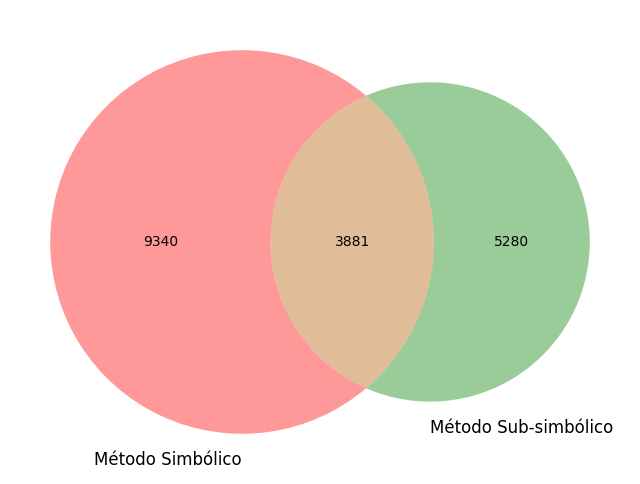

In [ ]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

venn2(
    subsets=(
        symbolic_wrong_only,
        subsymbolic_wrong_only,
        both_wrong
    ),
    set_labels=(
        "Método Simbólico",
        "Método Sub-simbólico"
    )
)

#plt.title()
plt.show()

In [ ]:
agreement = (
    df["symbolic_pred"] ==
    df["sub_pred"]
).mean()

print(f"Prediction agreement: {agreement:.2%}")

Prediction agreement: 63.98%


In [ ]:
symbolic_only_correct = df[
    (df["symbolic_pred"] == df["useful"]) &
    (df["sub_pred"] != df["useful"])
]

subsymbolic_only_correct = df[
    (df["symbolic_pred"] != df["useful"]) &
    (df["sub_pred"] == df["useful"])
]

both_wrong = df[
    (df["symbolic_pred"] != df["useful"]) &
    (df["sub_pred"] != df["useful"])
]

In [ ]:
pd.set_option('display.max_colwidth', None)
subsymbolic_only_correct[
    [
        "review",
        "useful",
        "symbolic_pred",
        "sub_pred"
    ]
].sample(20)

,review,useful,symbolic_pred,sub_pred
2390718,"O dinheiro mais bem gasto no Steam hoje, prato cheio para quem gosta de RPGs de mesa.",1,0,1
501207,Que jogo lindo.,1,0,1
667041,muito bom o jogo diversao garantida recomendo :D,1,0,1
1981326,"Melhor Assassin’s Creed da franquia.\n\nApesar de fugir um pouco da história dos três primeiros AC, esse com certeza, é o mais divertido e com melhor gameplay de todos.",1,0,1
2413815,"Resumo: o jogo saiu do alpha (early acess) mas ainda ta parecendo alpha: bugs, crash, performance ruim.\nEu não volto a comprar nem em promoção. Ainda bem que tem opção de reembolso.\n\nLi as reviews, me interessei pelo tipo de jogo mas não da pra jogar.\n\nAbre o jogo e ele roda em 5fps mesmo estando usando hardware dentro do recomendado.\nColoca todos os gráficos no low, desabilita tudo, coloca tudo pra melhorar a performance e fica em 25fps e caindo muito quando anda.\n\nCada vez que você muda certas opções precisa reiniciar o jogo. Cada vez que dou quit no menu do jogo ele trava e da crash. Tenho que finalizar o processo dele manualmente.\n\nFui mudar o tamanho da fonte, além dos botões não acompanharem o tamanho da fonte que você escolheu o jogo simplesmente da crash se você fica mudando o tamanho da fonte pra ver qual fica melhor.",0,1,0
1864419,"Mais um arcade feito apenas para divertir o pessoal que gosta de brincar!\nSe querem um jogo simulado nem percam tempo com esse arcadão! \nDepois do lançamento da Ferrari FS-15T no Assetto Corsa, a code deveria sentir vergonha alheia por lançar uma porcaria dessas.\n\n",0,1,0
1827258,Jogo de puzzle e suspense até que legalzinho.,1,0,1
1006404,"Vou dar um Deslike bem grande ,entro no battle royale mato uma galera quando chega perto do fim da partida me da erro FUUCKK game trash a sombra do antigo infestation survarior stories!",0,1,0
778583,"Fazia mais ou menos 25 anos que não jogava pac-man(epóca do Atari), e ainda assim tenho vontade de joga-lo. Simples e divertido, recomendo",1,0,1
127816,"Feito com amor. Little Misfortune tem um lugar cativo no meu coração e na minha biblioteca. É um jogo que você não vai demorar muito tempo pra finalizar, é possível fazê-lo em poucas horas, mas vale a pena. Trata de temas beeem difíceis de uma forma lúdica e estranhamente cativante. Onde há luz, há sombra.",1,0,1


In [ ]:
df.columns

Index(['recommendationid', 'language', 'review', 'timestamp_created',
       'timestamp_updated', 'voted_up', 'votes_up', 'votes_funny',
       'weighted_vote_score', 'comment_count', 'steam_purchase',
       'received_for_free', 'written_during_early_access', 'review_id', 'game',
       'author_steamid', 'author_num_games_owned', 'author_num_reviews',
       'author_playtime_forever', 'author_playtime_last_two_weeks',
       'author_playtime_at_review', 'author_last_played',
       'timestamp_dev_responded', 'developer_response', 'votes_log', 'is_pt',
       'tokens', 'token_count', 'sentence_count', 'average_sentence_length',
       'smog_grade', 'sent_intensity', 'feature_count', 'feature_density',
       'useful', 'average_sentence_length_norm', 'token_count_norm',
       'sentence_count_norm', 'sent_intensity_norm', 'smog_grade_norm',
       'feature_count_norm', 'nota_final', 'symbolic_pred', 'sub_pred'],
      dtype='object')

In [ ]:
#df[df["review"] == "Arida compensa os gráficos"][["symbolic_pred", "sub_pred", "useful"]]
# df[df["review"].str.contains("Arida compensa os gráficos", na=False)][
#     ["symbolic_pred", "sub_pred", "useful"]
# ]
# df[df["sub_pred"] == 1]["token_count"].mean()
df[df["symbolic_pred"] == 1]["weighted_vote_score"].mean()

np.float32(0.5995302)

In [ ]:
df["votes_funny"].corr(df["votes_up"])

np.float64(-0.002583769311776816)

In [ ]:
symbolic_only_correct[
    [
        "review",
        "useful",
        "symbolic_pred",
        "sub_pred"
    ]
].sample(20)

,review,useful,symbolic_pred,sub_pred
1960601,"Alguem me ajude estou tento problemas, não consigo jogar pois apenas saindo de áreas seguras, aparecem uns 30 zombies atras de mim e não importa o quando eu corra ou escale casas, eles me perseguem. já tentei mudar a dificuldade pro modo historia e continua do mesmo jeito",1,1,0
1158089,"Além do preço ser extremamente abusivo ( 47,49 ) É um jogo abandonado, o server br contém 100 pessoas da capacidade máxima com uma longa fila de espera além do ping ser alto.\n\nPositivos : \n[+1]Legenda em português\n[+1]Gráficos bonitos \n[+1]Varabielidade \n[+1]Veículos\n[+1]Armas \n\nContras :\n[-1]Preço alto. \n[-1]Jogabilidade estranha \n[-1]Sons péssimos \n[-1]Otimização fracassada. \nHurtworld é um jogo de construção, pvp e batalhas. \nNo game há animais, pessoas, construções e materias. ´\nUm jogo que provavelmente no futuro estará bom, no entanto, agora , não recomendo. \n\n3/5 \n",1,1,0
150301,"Vale muito a pena, pode confiar!\n\nO jogo já é lindo por ser BR, mas vou descrevê-lo um pouco:\n-Áudio: bom, focado em efeito do cenário, por exemplo, andar, moscas, etc;\n-Vídeo: bom, sinceramente me surpreendi, tenho um PC muito fraco e rodou tranquilamente em Full HD;\n-História: bom, o jogo é uma Ficção baseado em fatos que aconteceram de fato no nordeste do BR em 1895;\n-Bugs: Tem alguns, mas é engraçado, o animal anda até certo ponto do cenário e trava, mas suas patas continuam se mexendo como se estivessem andando, kkkkkkk;\n-Game: Finaliza em 1-3 horas (dependo do que fizer no jogo), mas se for concluí-lo totalmente (com conquistas) leva umas 7 horas. Algumas fáceis e outras medianas de conseguirem;\n-Bugs: Sim, as conquistas também podem ter bug, aconteceu de ter que recomeçar outro Save para conseguir a conquista;\n-Acabou? Não, terá a continuação e já estou louco para jogar.\n\nSuper recomendo!\nBom jogo para Vocês 💜💜💜",1,1,0
1415772,"O jogo em divertido, tem sistema de habilidades e equipamentos e uma história também. A unica coisa ruim nele é que não tem em português. Mas acho q vale a pena pelo preço.\nQuem quiser ver uma gameplay duvidosa de um individuo também com uma tradução deveras duvidosa ta ai https://youtu.be/BkSPFOLfk1c\nbjonabunda",1,1,0
2333718,"Primeiramente deixe-me começando dizendo VAI SE FERRAR EXECUTIONER BICHO DO CAPETA COMO DUELA CONTRA ESSE NEGÓCIO ENFIA ESSE TEU MACHADO NO C*! \n\n*cof cof* \n\nPassado isso, recebi o game de graça dos devs, e normalmente eu adoro games de carta. Imaginava que esse seria mais um game do tipo heartstone ou algo assim sabem? batalhas e etc, pvp, então fui adiando esse teste dele. \nBom, não era nada do que eu pensava, se mostrou melhor, um game naquele estilo Solitaire e associados, mas que introduz alguns conceitos novos, como é o caso da batalha e de ter um personagem fixo no qual podemos equipar itens, como se fosse um RPG ou coisa do tipo, com direitos a mercantes e etc.\nDe fato, não é um game pra qualquer um, e digo isso por que apesar da dificuldade do ultimo modo, ele continua sendo um game ""casual"" e nem todo mundo curte ficar pensando qual sequencia de cartas puxar pra fazer o maior combo, porém, se tu curte jogos como... faerie solitaire, pode comprar com toda certeza.\n\nAHHH o jogo tambem tem uma história, e pelo que li parece interessante, confesso que meu foco é outro, então fui pulando as cutscenes, falha minha =P ou seja, só posso atestar pelas mecanicas e jogabilidade nesse review.\nO jogo tambem tem uma aparencia bacana, simples mais satisfatória. \n\nEnfim, apesar de achar o preço meio salgado, confesso que o game parece valer o que está sendo cobrado. E fica aqui minha recomendação positiva do mesmo.",1,1,0
942341,"Cara.. não é bom. SF 4 é MUITO melhor que essa bosta. :/ \nHype nesse jogo foi em vão, a galera só joga e vai nos camps pelo dinheiro.\n\n@edit: 2019, fui tentar voltar a jogar, 20 minutos pra achar uma partida, jogo completamente LAGADO. Tenho fibra com 200mb de up e o jogo tem LAG. CRAPcom.\n\n

In [ ]:
both_wrong[
    [
        "review",
        "useful",
        "symbolic_pred",
        "sub_pred"
    ]
].sample(20)

,review,useful,symbolic_pred,sub_pred
215810,Bem estilo N64! Roda bem no Ubuntu 20.04. \n,1,0,0
388218,"Para quem curte um modo sobrevivência é um jogo muito bom.....\nApós as ultimas atualizações o jogo melhorou bastante, não tive a oportunidade de testar 100% das att mas esta muito bom....\no único problema é q o save buga quando tem uma att nova...\n\nEDIT:\n25/07/2018\nApós essa a NMS NEXT o jogo me surpreendeu muito. Mesmo o povo falando q era isso q a HG tinha q trazer desde o inicio, o jogo se superou. Existem coisas no jogo que podem melhorar, sim existem, então vamos esperar uma proxima att pra ficarmos mais felizes ainda.\nRecomendo o jogo mais que nunca.",0,1,1
2286043,"Bem mal optimizado quedas de fps constantes , bugs bugs e mais bugs ...",1,0,0
2417045,1000 grau cola ae no meu server pra nos jogarmos juntos https://discord.gg/upn23uS,1,0,0
1434670,"𝐌𝐄 𝐃𝐄𝐑𝐀𝐌 𝐔𝐌𝐀 𝐀𝐑𝐌𝐀. 𝐎 𝐐𝐔𝐄 𝐕𝐎𝐂Ê 𝐄𝐒𝐏𝐄𝐑𝐀𝐕𝐀 𝐐𝐔𝐄 𝐄𝐔 𝐅𝐈𝐙𝐄𝐒𝐒𝐄?❓\n⠏⢠⠖⠉⠄⠄⠄⣠⠎⠄⠄⣰⠋⢠⡆⠠⡄⠄⠄⠄⠹⡄⠄⠄⠈⠳⣄⠄⠄⠄\n⣰⠃⠄⠄⠄⠄⡰⠁⠄⠄⢀⠏⠄⢼⡀⢀⡇⠄⠄⠄⡆⣧⠄⠄⣆⠄⠈⡆⠄⠄\n⠃⠄⠄⠄⠄⣰⠃⠄⠄⣠⡾⠄⢰⣦⡁⢸⠁⠄⠄⠄⡇⢸⠄⠄⢸⠄⠄⢻⠄⠄\n⠄⠄⠄⡖⢠⠇⠄⣠⣾⣿⡇⣴⣿⣿⣷⠌⠄⠄⠄⢠⠇⠸⡄⠄⢸⠄⠄⠈⢧⠄\n⠄⠄⠄⡇⠘⣤⣾⣿⣿⣿⠿⠿⣿⣿⡏⠄⠄⠄⠄⣰⣆⣶⣤⠄⢸⠄⠄⠄⠸⡆\n⡞⠄⠄⢳⢈⠉⣀⣄⠄⠄⠉⠒⣦⣽⣤⣶⣾⣿⣿⣿⣿⣿⣿⠄⢸⠄⠄⠄⠄⣿\n⠃⠄⠄⠸⣿⣷⣝⣏⣀⠄⢻⠆⣿⣿⣿⣿⣿⣿⣛⣛⣻⣿⣿⠄⠄⠄⠄⠄⠄⢸\n⠄⠄⠄⠄⢸⣿⣿⣿⣿⣿⣶⣿⣿⣿⣿⣿⣿⣿⠄⠈⠙⢿⣿⣠⡎⠄⠄⠄⢀⠘\n⠄⠄⠄⣆⠈⣿⡿⠿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣯⣅⡀⣽⢄⣽⡟⢸⢠⠄⠄⢸⠄\n⡇⠄⠄⢸⡆⢹⣷⣌⡻⡿⠿⢿⣿⣿⣿⣿⣿⣿⣿⣿⣶⣿⡿⠁⡿⢸⠄⠄⢸⢸\n⣼⡀⠄⠘⣿⣌⣿⣿⣿⣶⣭⣛⡳⠮⣙⢿⡿⣿⣿⣿⣿⡿⠄⢠⡇⡾⠄⠄⡟⣸\n⢸⢣⠄⠄⢹⣿⣾⣿⣿⣿⣿⡿⠛⣿⣷⣶⣶⣿⣿⣿⣿⠇⠄⣼⢠⠇⠄⢸⢇⡟\n⢸⠄⠱⣄⠈⠻⣿⣿⣿⣿⣿⣿⣦⣿⣿⣿⣿⣿⣿⣿⠏⢰⣆⠇⡎⢀⡴⢻⡼⠁\n⢸⠄⠄⢹⠐⠳⢌⠛⢿⣿⣿⣿⣿⣿⣿⣿⡿⠟⢋⡀⠄⣾⣟⣸⠖⠃⠄⠈⠃⠄\n⠄⠄⠄⢸⡌⠉⠒⢭⠢⣌⡛⠛⠿⠛⠉⠁⢰⠃⣼⡇⣸⣿⣿⠃⠄⠄⠄⠄⠄⠄ \n\n⠏⢠⠖⠁⠄⠄⠄⣠⠎⠄⠄⣠⠋⢠⡆⠠⡄⠄⠄⠄⠹⡄⠄⠄⠈⠳⣄⠄⠄⠄\n⡰⠃⠄⠄⠄⠄⡰⠁⠄⠄⡠⣿⣄⣼⡀⢀⡇⠄⠄⠄⡆⣧⠄⠄⣆⠄⠈⡆⠄⠄\n⠃⠄⠄⠄⠄⣰⠃⠄⣠⠞⠁⣿⠏⠛⢧⣸⠁⠄⠄⠄⡇⢸⠄⠄⢸⠄⠄⢻⠄⠄\n⠄⠄⠄⡖⢠⠃⣰⠛⠁⠄⢰⠋⠄⠄⠈⣸⠄⠄⠄⢠⣧⣼⡄⠄⢸⠄⠄⠈⢣⠄\n⠄⠄⠄⡇⢸⠊⠁⠄⠄⠄⣀⣀⡀⠄⢰⡇⣀⣀⣰⠏⣏⡝⣿⠂⢸⠄⠄⠄⠸⡆\n⡎⠄⠄⣷⡏⣴⢺⠛⣿⣷⣦⣉⠙⠂⠊⠉⠁⠄⠄⠄⠄⠄⢻⠄⢸⠄⠄⠄⠄⢿\n⠃⠄⠄⢸⡀⠙⠦⣴⣿⣿⡀⣹⠄⠄⠄⠄⠄⠄⠛⠷⠄⠄⢸⠄⣼⠄⠄⠄⠄⢸\n⠄⠄⠄⠄⢹⣦⣀⠄⠄⠈⠉⠁⠄⠄⠄⠄⠄⡤⢿⣷⣤⡀⠸⠴⢸⠄⠄⠄⢀⠘\n⡀⠄⠄⣆⠘⣿⡿⠿⣦⣤⣤⣶⣶⣶⡶⠂⠄⠓⠺⣿⡀⡹⠂⡠⢹⢠⠄⠄⢸⠄\n⣇⠄⠄⢰⡄⢻⣷⣌⡻⡿⠿⢿⣿⣿⡇⠄⠄⣧⡀⠈⠉⠄⣴⠁⡿⢸⠄⠄⢸⢸\n⣼⡀⠄⠸⣿⣜⣿⣿⣿⣶⣭⣛⡳⠮⣻⢆⡴⣿⣿⣷⣤⡶⠁⢠⡇⡞⠄⠄⡞⣸\n⢸⢧⠄⠄⢿⣿⣾⣿⣿⣿⣿⡿⠛⣿⣷⣶⣶⣿⣿⣿⣿⠇⠄⣸⢣⠇⠄⢸⢇⡟\n⢘⠄⠑⣄⠈⠻⣿⣿⣿⣿⣿⣿⣦⣿⣿⣿⣿⣿⣿⣿⠋⢰⣄⡏⡎⢀⡴⢻⡼⠁\n⢸⠄⠄⢻⠐⠳⢌⡛⢿⣿⣿⣿⣿⣿⣿⣿⡿⠟⢋⡅⠄⣾⣟⣸⠖⠃⠄⠈⠃⠄\n⠄⠄⠄⢸⡌⠉⠒⢭⠲⣍⣛⠻⠿⠛⠉⠁⢰⠃⣼⡇⣸⣿⣿⠃⠄⠄⠄⠄⠄⠄ \n\n█▀ █ █▀▄▀█ █▀▀ █░█ ▄▀█ █░█ █▀ █▀▀ █ \n▄█ █ █░▀░█ ██▄ █▄█ █▀█ █▄█ ▄█ ██▄ █ \n\n█▀▄ ▄▀█ █▀▄▀█ █▀▀ █░░ █░█ █▀█ █▀█\n█▄▀ █▀█ █░▀░█ ██▄ █▄▄ █▀█ █▄█ █▀▄\n\n█▀▀ █▀█ █▀█ █▀▄▀█ ▄▀█ █▀█ █░█ █▀▀\n█▀░ █▄█ █▀▄ █░▀░█ █▀█ ▀▀█ █▄█ ██▄\n\n█▀█ █▀█ █▀▄ █▀▀ █ █▀▄▀█ ▄▀█ █▀▀ █ █▄░█ ▄▀█ █▀█\n█▀▀ █▄█ █▄▀ ██▄ █ █░▀░█ █▀█ █▄█ █ █░▀█ █▀█ █▀▄\n\n\nSegue a dica:\n1º) Vá no site do RetroArch > Downloads, Desce a pagina e não baixe o ""Instaler"", baixe apenas o ""Download (64bit)"" ou ""Download (32bit)""\n\n2)Desompacta o arquivo e copie tudo que você descompactou.\n\n3) Vá na pasta do RetroArch (C:\Program Files (x86)\Steam\steamapps\common\RetroArch) , cole tudo lá, substituindo todos os arquivos.\n\nPronto, agora vc tem habilitado a opção de Downloads direto pelo RA, podendo baixar núcleos e tumbnails mais facil.",0,1,1
374524,Jogo bem realistico. Flata Silenciadores!!,1,0,0
2573796,Melhor que PIFA.,1,0,0
2661467,"-""Se vira no game"" simulator!",1,0,0
2287687,"Põe legenda PT-BR nessa joça, por favor!",1,0,0
536069,Ignoraram jogadores PVE.,1,0,0


## Análise de Falsos Positivos

In [ ]:
symbolic_fp = (
    (df["useful"] == 0) &
    (df["symbolic_pred"] == 1)
)

subsymbolic_fp = (
    (df["useful"] == 0) &
    (df["sub_pred"] == 1)
)

In [ ]:
fp_both = (
    symbolic_fp &
    subsymbolic_fp
).sum()

fp_symbolic_only = (
    symbolic_fp &
    ~subsymbolic_fp
).sum()

fp_subsymbolic_only = (
    ~symbolic_fp &
    subsymbolic_fp
).sum()

In [ ]:
print("Shared FP:", fp_both)
print("Symbolic-only FP:", fp_symbolic_only)
print("Subsymbolic-only FP:", fp_subsymbolic_only)

Shared FP: 662
Symbolic-only FP: 1333
Subsymbolic-only FP: 352


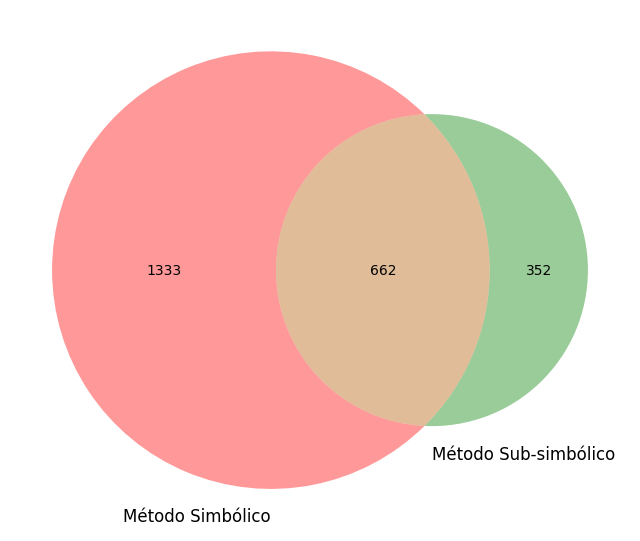

In [ ]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

venn2(
    subsets=(
        fp_symbolic_only,
        fp_subsymbolic_only,
        fp_both
    ),
    set_labels=(
        "Método Simbólico",
        "Método Sub-simbólico"
    )
)

plt.show()

In [ ]:
shared_fp = df[
    symbolic_fp &
    subsymbolic_fp
]

symbolic_only_fp = df[
    symbolic_fp &
    ~subsymbolic_fp
]

subsymbolic_only_fp = df[
    ~symbolic_fp &
    subsymbolic_fp
]

In [ ]:
subsymbolic_only_fp["token_count"].mean()

np.float64(13.400568181818182)

In [ ]:
symbolic_only_fp[
    ["review", "useful", "symbolic_pred", "sub_pred", "token_count"]
].sample(20)

,review,useful,symbolic_pred,sub_pred,token_count
1063949,"Mano, simplesmente o melhor jogo no estilo caçada FPS. A trocação é insana!!\nMorreu, Morreu!!",0,0,1,22
801467,muito bom principalmente online com amigos recomendo,0,0,1,7
399058,"Comprem Armello seus arrombados, eu sei q vcs tão lendo isso e se perguntando, nossa é 40 reais, mas fodasse compra q é mto bom.",0,0,1,29
1831589,Sugando sua vida,0,0,1,3
2429304,vai toma no cu esse jogo do caralho,0,0,1,8
2577277,melhor jogo de pesca!!!! segura aqui meu like!!!!,0,0,1,16
864043,MTO BOM PENA QUE AGR NINGUEM LEVA A SÉRIO O GAME !!,0,0,1,13
790296,Otimo Jogo,0,0,1,2
1543271,"PARÇA esse jogo EH MUITO BALA!!!\nPOTAQUEOPAROLHAS MOLEQUE\nDALE DELE DELE DOLLY, É LEGIT O MELHOR ROGUELIKE Q JA JOGUEI\nJOGUE AGORA",0,0,1,26
2622821,"JOGO BUGADO DEMAIS 6,9",0,0,1,4


In [ ]:
subsymbolic_only_fp[
    ["review", "useful", "symbolic_pred", "sub_pred"]
].sample(20)

,review,useful,symbolic_pred,sub_pred
783299,Muito bom para passar o tempo. Mas não tente jogar se não tiver muita paciência haha XD,0,0,1
192348,muito bom e tem teta,0,0,1
168538,O jogo seria incrível se rodasse :),0,0,1
1146926,"muito bom recomendo, para quem busca um Dark Souls futurístico esse é o game!",0,0,1
1171737,"Meu avô fumou durante sua vida inteira. Eu tinha cerca de 10 anos quando minha mãe disse a ele, ‘Se você quiser ver seu neto se formar, você precisa parar imediatamente.’. Lágrimas saíram de seus olhos quando ele percebeu o que realmente estava em jogo. Ele parou de fumar imediatamente. Três anos depoius ele faleceu de câncer nos pulmões. Eu estava realmente triste e aquilo me destruiu. Minha mãe me disse- ‘Nunca fume. Por favor não faça sua família passar pelo que o seu avô nos fez passar.’ Eu concordei. Aos 20, eu nunca toquei em um cigarro. E preciso dizer, eu sinto um pouco de arrependimento de nunca ter feito isso, porque, de qualquer jeito, esse jogo me deu câncer.",0,0,1
71377,Jogo foda mano amei,0,0,1
924086,"Sem duvidas, um dos melhores jogos que eu ja comprei! Eu acompanho a franquia desde o 2º game, mas esse veio pra diferenciar o aspecto GTA. Mantendo a mesma mecânica, Saints Row ""V"", tem varios diferenciais que todos iram curtir bastante.\n10/10",0,0,1
1032360,Depois de algumas horas ate que não parece ruim,0,0,1
1408188,"Jogão! Gostei muito! Divertido, desafiador e com uma ótima trilha sonora!",0,0,1
1413571,"Jogo maravilhoso demais, pode comprar",0,0,1


In [ ]:
shared_fp[
    ["review", "useful", "symbolic_pred", "sub_pred"]
].sample(20)

,review,useful,symbolic_pred,sub_pred
1408279,"Muito divertido quando se tem mais pessoas para jogar, porem é muuuuuito curto o jogo.",0,1,1
781276,"Joguei por mais de uma hora,e ja me maravilhei com esse jogo!\n\nVoce pode joga-lo totalemente stealth\nA IA é muito boa,mesmo no EASY\nGraficos bons\n\nSem mais.",0,1,1
457763,"Ótimo jogo de puzzle point and click.\nA história é boa, mas oque se destaca pelo jogo inteiro é a arte.\nVale a pena para quem gosta desse estilo de jogo.",0,1,1
150447,"É um jogo curto, porém muito interessante e visualmente bonito. E o melhor é que trata-se de um jogo brasileiro.",0,1,1
2102848,"Bom é um joguinho legal melhor que o Tera, porém demorou muito para vim par ao ocidente e quando chega vem com os msm problemas de otimização por causa da unreal 3. É um jogo 7/10, e não durara 3 meses com esses 30k de player on, e em 6 meses cairá para uns 10k de players on !",0,1,1
2408525,"Não diria um otimo game para PC,Mais para consoles um otimo game,Recomendadissimo =D",0,1,1
2347105,"Um clássico jogo de estratégia, que permite uma infinidade de personalizações.\nDificuldade elevada com estilo bem retrô.",0,1,1
383494,"Aura Kingdom é um jogo MMORPG de fantasia gratuito para jogar com gráficos 3D estonteantes estilo Anime. Você pode escolher uma de onze classes diferentes e então adicionar habilidades para fazer a sua personagem única e se adaptar mais ao seu estilo de jogabilidade.\nÉ fácil ver porque muitos jogadores se apaixonaram pelo mundo de Azuria! Na sua aventura, você vai andar ao lado de Eidolon um companheiro leal e interativo que lhe dá grande força em qualquer batalha, seu Eidolon pode também lembrar as suas ações, e lhe dizer o que está em sua mente.\n\n\nA ação do mundo de Aura Kingdom é rápida e dinâmica. Você tem que ter certeza que você está na sua melhor condição de jogo, e agir rápido são as chaves para o resultado de sucesso nas batalhas. Não resmungue com o seu personagem, você pode se contornar cada desafio que você encarar. Simplesmente melhore as habilidades que melhor se encaixam no seu estilo de jogabilidade ou rapidamente mude as suas habilidades durante a batalha, então você estará pronto para enfrentar os oponentes que vai encontrar no seu caminho.\n\n você pode viajar na vasta terra de Azuria e visitar a grande cidade de Navea, um refúgio sagrado. Ou visitar a Costa Helonia sendo conhecida por ser o coração do mercado negro caso você precisar de comprar qualquer coisa, você pode encontrar aqui! Você também visitará o Pântano de Candeo e a Floresta Oblitus, entre outros lugares e explorar masmorras misteriosas e escondidas para destruir o mal que prevalece no escuro. Você pode se tornar um herói!",0,1,1
2756218,"O jogo é mt bom para passar o tempo, tem uma ótima musica de fundo (eu acho que poderiam ser várias) e tem fases bem divertidas.",0,1,1
974078,jogo caro e muito bom mas e caro porem e bom mas pode ser caro e tbm pode ser bom as vezes pode ser caro e chato porem continua sendo bom e barato,0,1,1


## Análise de Falsos Negativos

In [ ]:
symbolic_fn = (
    (df["useful"] == 1) &
    (df["symbolic_pred"] == 0)
)

subsymbolic_fn = (
    (df["useful"] == 1) &
    (df["sub_pred"] == 0)
)

In [ ]:
fn_both = (
    symbolic_fn &
    subsymbolic_fn
).sum()

fn_symbolic_only = (
    symbolic_fn &
    ~subsymbolic_fn
).sum()

fn_subsymbolic_only = (
    ~symbolic_fn &
    subsymbolic_fn
).sum()

In [ ]:
print("Shared FN:", fn_both)
print("Symbolic-only FN:", fn_symbolic_only)
print("Subsymbolic-only FN:", fn_subsymbolic_only)

Shared FN: 3219
Symbolic-only FN: 8007
Subsymbolic-only FN: 4928


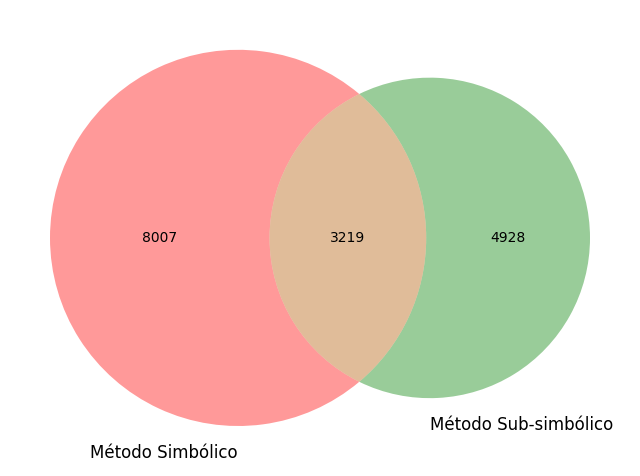

In [ ]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

venn2(
    subsets=(
        fn_symbolic_only,
        fn_subsymbolic_only,
        fn_both
    ),
    set_labels=(
        "Método Simbólico",
        "Método Sub-simbólico"
    )
)

plt.show()

In [ ]:
shared_fn = df[
    symbolic_fn &
    subsymbolic_fn
]

symbolic_only_fn = df[
    symbolic_fn &
    ~subsymbolic_fn
]

subsymbolic_only_fn = df[
    ~symbolic_fn &
    subsymbolic_fn
]

In [ ]:
symbolic_only_fn[
    ["review", "useful", "symbolic_pred", "sub_pred"]
].sample(20)

,review,useful,symbolic_pred,sub_pred
610127,"Só uma palavra SENSACIONAL. A história é cativante tanto com o Nero, quanto com o Dante. No futuro quem sabe jogue o Special Edition.",1,0,1
1121707,Uma continuação e evolução maravilhosa de tudo que a franquia já entrgou anteriormente,1,0,1
1436469,"Uma mistura de stardewvalley e graveyard keeper, porém em proporções menores, o jogo tem muito futuro, estou curtindo bastante!",1,0,1
1879009,"Permite uma flexibilidade de configuração fantástica, desde as configurações mais avançadas de cada veículo, assim como os modos mais simples, apenas para quem gosta só de curtir o game.\n\nJOGO.... MADNESS!!!",1,0,1
737793,Esse mod faz do velho company um novo jogo.\n\nMissões co-op\nNovas doutrinas\nNorte da áfrica com exércitos únicos\nExércitos específicos para certos mapas\nMuitos mapas\nMuito mais unidades\nFicou mais dificil,1,0,1
319879,melhor jogo tanto em qualidade tanto em jogabilidade,1,0,1
624673,Muito bom. Sons realista. Com o tempo ficará melhor.,1,0,1
331357,Toda a tecnologia moderna dos games do século XXI utilizada para recriar a magia do clássico do Mega Drive e consegue não só isso como ir um pouco além. Ótimo para introduzir a molecada de hoje no mundo dos games. Excelente para os veteranos terem uma noção de como seria na época deles com a tecnologia de hoje.,1,0,1
1048190,"ESSE JOGO É MUITO BOM, JOGUEM!!!\n\n<3",1,0,1
548100,"Só Skin top , recomendo , '' Aim mais 35 real '' Compra quem quer KRL , Melhor doque pagar 20 conto em uma só skin na loja :D",1,0,1


In [ ]:
subsymbolic_only_fn[
    ["review", "useful", "symbolic_pred", "sub_pred"]
].sample(20)

,review,useful,symbolic_pred,sub_pred
325051,"Homefront: The Revolution conta com diversas ideias interessantes porém mal executadas. A intenção dos desenvolvedores foi criar um FPS com elementos de guerrilha urbana, com esquema muito parecido de Far Cry de tomar bases e facilitar a tomada do mapa para realizar missões. No entanto, o jogo apresenta muitos problemas que incomodam:\n\n- Bugs em missões secundárias\n- Bugs em gráficos, principalmente se seu set de hardware é AMD\n- IA dos inimigos muito mal programada\n- Situações repetidas em diversos momentos do jogo\n- História terrivelmente ruim, algo que impacta muito games que tem foco no single player\n- MP sem graça e descartável\n\nMesmo pegando o jogo em promoção de 75%, não recomendo Homefront, pois é um jogo que passa a impressão que foi desenvolvido na base da preguiça. Existe uma tonelada de jogos melhores no mercado hoje em dia.",1,1,0
343889,"Realmente é um jogo que vale apena comprar, mas é claro, se for jogar com amigos, se não tiver amigos para jogar o jogo vai ficar sem graça, e vai enjoar rápido\n",1,1,0
1035760,"O jogo possui muito potencial, sendo que já é famoso e reconhecido, mas possui grandes problemas de otimização e quedas de FPS inaceitáveis fazendo a maioria dos jogadores utilizar os gráficos no minimo. Promove Rage-Quit na maioria dos jogadores. Alem do mais não há a possibilidade de escolher servidores próximos a você pois é aleatório em qual server irá entrar.\n6/10",1,1,0
1069140,"O mesmo jogo. Novo visual, novas opções e a possibilidade de escolher o layout da tela. Os controles também podem ser realizados pelo mouse ou gamepad. A remasterização é competente e o relançamento foi uma boa coisa. Mas essa versão carece de um elemento essencial:\n\nLEGENDAS!!!! Putz! Apesar de o inglês usado ser bem acessível e de fácil compreensão, a qualidade sonora não ajuda muito. Num fone de ouvido dá pra entender tudo ou quase tudo. Num ambiente aberto e com um pouco mais de ruídos, já dá pra perder alguns diálogos. Que é que custava? São tão poucos os diálogos!\n\nVou recomendar, mas acho que essa farrapada é injustificável.",1,1,0
558374,"Compensa muito pegar o upgrade para quem não tem todos os personagens e cenários, pois, nele vem praticamente tudo, todos os personagens, todas as roupas ""fora da cpt e fight chance"" todas as cores por um preço bem baixo se coloca tudo o que vem na balança passa fácil dos 700 reais.",1,1,0
2591326,"Jogo infestado de hackers. Você perde um tempo do caralho pra upar o seu personagem, joga com lag no park pq não tem servidor SA e ainda tem que lidar com cheaters em todas as partidas achando que jogam bem com um pivô 7'3'' speed full, full ball handle e full three point. Empresa patética, mantém essa merda de jogo e não coloca a porra de um anticheat. Em todas as edições do jogo no PC o jogo fica infestado de cheaters com 50 metros de braço e 200 metros de perna.",1,1,0
2688211,"As ultimas atualizações do jogo estão sendo feitas apenas para ganhar dinheiro em cima dos jogadores, agora o jogo se tornou um pay-to-win, se você quer ser top nesse jogo prepare-se para gastar muito dinheiro.",1,1,0
2339022,o jogo e muito bom só que a comunidade dele e horrivel nao tem como voce jogar em nenhum servidor todos que voce entra tem um lvl alto abusando de jogadores novos raidando pegando todos itens joguei em 5 servidores diferentes todos foram assim eles vem e fazem o que quer somente ia fica bom esse jogo com wipe no servidor do jeito que esta nao presta pra nada,1,1,0
1104154,"A historia é boa, creio ser a melhor historia entre a trilogia. A jogabilidade é fluida, puzzles legais. Na minha opinião, existem três pontos negativos nesse jogo: A trilha sonora (na hora do combate toca um rock 'nada a ver'). Desnecessariamente longo, você tem que ""ir e vir"" muitas vezes nos mesmos mapas, é cansativo. E é muito bugado, eu fui lutar contra um boss e, após passar um perrengue da porra pra matar a infeliz, o jogo vai e crasha, e não foi só u

In [ ]:
shared_fn[
    ["review", "useful", "symbolic_pred", "sub_pred"]
].sample(20)

,review,useful,symbolic_pred,sub_pred
2546734,"bom , porem existem poucos modos de treinar a mira",1,0,0
1155163,um cú,1,0,0
2653395,quero que o jogo fique de graça pra meu amgio poder pegar freee. ele e probe e nao poder compraaa,1,0,0
2598285,"Melhor jogo, comprei o pacote Ultimate de deuses, pedi reembolso, e continuei com os deuses na conta, STONKS\n\nEDIT: Eu não sabia que os deuses continuariam na conta.",1,0,0
100634,370 reais jogados no lixo :S,1,0,0
1202134,nice recomended,1,0,0
2080641,"UMA MERDA, SÓ CRASHA!!!",1,0,0
2035787,"Simplesmente impossível jogar, ping alto e dc a todo momento. A Zenimax tem que se tocar que existem fans da franquia no Brasil e na America do sul como um todo.",1,0,0
139010,"meu histórico.\n\ntentativa 01 - dia 01\n- picado por cobra. morto.\n\ntentativa 02 - dia 01\n- fiz fogo na entrada de uma caverna, índios vieram investigar. morto\n\ntentativa 03 - dia 01\n- o inicio da noite é mto escuro, sai caminhando e caí, me feri. pra ajudar tb fui picado por uma aranha. morto\n\ntentativa 04 - dia 01\n- cansado dormi no chão, acordei infectado por larvas na pele. não encontrei comida, comi cogumelo. cogumelo errado. bebi agua, contrai parasitas. vomitei sem parar. morto\n\ntentativa 05 - dia 01\n- bebi agua suja. chovia sem parar, não consegui fazer fogo. precisava de comida, comi larvas. dormi no chão, larvas na pele de novo. sanidade foi pra zero. falava comigo mesmo o tempo todo. um índio surgiu na minha frente, acertei com a lança. sumiu. era alucinação?? continuei vagando, depois de algumas horas surgiu outro indio. morto.\n\ntentativa 06\ndia 01\n- sanidade em zero de novo. caminhava alucinando pela selva e encontrei uma vila. descobri como fazer água (pulos de alegria). cacei uma capivara. dormi numa rede. loucura começou a curar. sobrevivi o primeiro dia.\n\ndia 02\n- fazendo comida. onça me atacou. matei a onça. tô ferido por todos os lados. consegui fazer bandages em todas. infecionou. morto.\n\nAtualmente, depois de mais algumas tentativas fracassadas, estou vivo por 15 dias. descobri como fazer uma forja e um veio de ferro numa caverna. ansioso por um blacksmithing. na caverna fui picado por um escorpião. veneno tratado mas a febre não baixa. quase morro de sede. sobrevivo.\né noite, vou dormir. escuto barulho. é só uma anta. me viro e tem uma onça me encarando. atiro uma flecha, erro mas ela se assusta e foge. sobrevivo mais 1 dia.\n\ngame muito bom!",1,0,0
2761761,O CARA COMEU MINHA PLANTA MEU,1,0,0


In [ ]:
df[df["sub_pred"] == 1]["token_count"].mean()

np.float64(143.78158119939437)

In [ ]:
df["token_count"].mean()

np.float64(129.38129141928013)

In [ ]:
df_filtrado.sample(10)

NameError: name 'df_filtrado' is not defined

In [ ]:
df = pd.read_pickle("df_pt.pkl")

In [ ]:
df["weighted_vote_score"] = df["weighted_vote_score"].astype(float)
df["useful"] = (df["weighted_vote_score"] > 0.5).astype(int)

In [ ]:
df['useful'].value_counts()

In [ ]:
df[["votes_norm", "weighted_vote_score"]]